# Difference in Normalized Burn Ratio (dNBR) for Fire Area Detection using OpenEO

The main goal of this project is to analyse the impact of forest fires in Portugal. The exact area that was burned in a forest fire is delineated and the burned trees are identified using machine learning methods. 

The measurement of the impact is split into two parts: the area of the forest that was burned in the forest fire, and the types of vegetation that were burned.
The burned area is identified based on Sentinel-2 images, using the difference in normalized burn ratio (dNBR). For the burned area, labels derived from the national forest inventory are loaded, and used to train a machine learning algorithm to identify the vegetation types in each pixel. This can be used to make an estimate of the composition of the forest and to identify how many hectares of which type of vegetation were burned.

Key Processes:
1. Calculate dNBR based on image before and after fire
2. Identify composition of the burned forest before the fire using ML
3. Register a UDF for ML
4. Create a story powered by EOPF OpenEO

# Overview

1. Import required libraries
2. Connect to OpenEO backend
3. dNBR Fire Area Detection
   - 3.1 Load pre and post fire satellite images
   - 3.2 Calculate dNBR and fire mask
   - 3.3 Visualize dNBR
   - 3.4 Export fire pixel coordinates
4. ML Vegetation Classification
   - 4.1 Load NFI labels on the burned area
   - 4.2 Define ML pipeline
   - 4.3 Train Random Forest classifier
   - 4.4 Apply classifier to satellite image

## 1. Import Required Libraries

In [ ]:
import os
import json

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import rasterio
import geopandas
from rasterio.transform import rowcol
from rasterio.transform import xy as rasterio_xy
from scipy import ndimage
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import openeo
from openeo_udp import ParameterManager

## 2. Connect to OpenEO Backend

In [44]:
# Initialize parameter manager
param_manager = ParameterManager('dNBR_Portugal.params.py')

# Display available options using the built-in helper
param_manager.print_options("dNBR algorithm")

Available parameter sets for dNBR algorithm:
  1. forest_north_portugal_2025: Forest, North Portugal
  2. reriz_gafanhao_north_portugal_2024: Reriz e Gafanhao, North Portugal

Available OpenEO endpoints:
  1. copernicus_dataspace: https://openeo.dataspace.copernicus.eu/
  2. ds_development: https://openeo.ds.io/
  3. eopf_explorer: https://api.explorer.eopf.copernicus.eu/openeo
  4. localhost_dev: http://localhost:8082/

💡 Tip: Use param_manager.interactive_parameter_selection() for interactive selection,
or param_manager.quick_connect('set_name', 'endpoint') for direct connection.
To change selections, use the interactive widgets in the next cell.


In [45]:
# Connect using the a parameter set for a specified location on the Copernicus Data Space endpoint
connection, current_params = param_manager.quick_connect(
    param_set="reriz_gafanhao_north_portugal_2024",
    endpoint="copernicus_dataspace", # Connecting to CDSE
)

🔄 Connecting to copernicus_dataspace...
📍 Using parameter set: reriz_gafanhao_north_portugal_2024
Authenticated using refresh token.
✅ Successfully connected to copernicus_dataspace
✅ Parameters loaded and mapped for: Reriz e Gafanhao, North Portugal
🔄 Parameters mapped for endpoint copernicus_dataspace:


## 3. dNBR Fire Area Detection

### 3.1 Load Pre and Post Fire Satellite Images

In [46]:
# First define functions to use for loading image and calculating NBR
def load_and_sample(params, time, bands, res=100):
    """
    Input: Set of parameters, time frame, desired resolution
    Output: Cube that contains the last image in the time frame 
    """ 
    s2cube = connection.load_collection(
    params["collection"].default,
    temporal_extent=time,
    spatial_extent=params["bounding_box"].default,
    bands=bands,
    properties={
        "eo:cloud_cover": lambda x: x <= params["cloud_cover"].default,
    },
    )

    s2cube = s2cube.reduce_dimension(dimension="t", reducer="last")

    s2cube = s2cube.resample_spatial(
        resolution=[res, res],
      method="near",
    )

    return s2cube

In [47]:
# Define Resolution
res_dnbr = 20

# Load Satellite image before and after the fire as cubes
s2cube_pre = load_and_sample(current_params, current_params["time_pre"].default, current_params["bands_fire"].default, res_dnbr)
s2cube_post = load_and_sample(current_params, current_params["time_post"].default, current_params["bands_fire"].default, res_dnbr)

### 3.2 Calculate dNBR and Fire Mask

In [48]:
def calculate_nbr(data):
     """ 
     Input: Cube with bands 08 and 12
     Output: NBR
     """
     B08, B12 = (
          data[0],
          data[1],
     )
     nbr = (B08 - B12) / (B08 + B12)
     return nbr

def calculate_dnbr_and_mask(nbr_pre, nbr_post, burn_threshold):

     """Input Pre and Post Fire NBR as cube, burn threshold
     Output: dNBR and dNBR mask"""
     
     dnbr = nbr_pre - nbr_post
     dnbr_mask = dnbr > burn_threshold
     return dnbr, dnbr_mask

In [49]:
# Calculate NBR of pre and post cube
nbr_post = s2cube_post.reduce_dimension(dimension="bands", reducer=calculate_nbr)
nbr_pre = s2cube_pre.reduce_dimension(dimension="bands", reducer=calculate_nbr)

burn_threshold_default = 0.3
dnbr, dnbr_mask = calculate_dnbr_and_mask(nbr_pre, nbr_post, burn_threshold_default)

In [50]:
# Download dNBR
dnbr_tiff = dnbr.save_result("GTiff")
filename = f"dNBR_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.tiff"
connection.download({"process_graph": dnbr_tiff.flat_graph()},filename)

# Download masked dNBR
mask_result = dnbr_mask.save_result("GTiff")
filename_mask = f"firemask_{current_params['location_name'].replace(' ', '_').replace(',', '').lower()}.tif"
connection.download({"process_graph": mask_result.flat_graph(),}, filename_mask)

### 3.3 Visualize dNBR

In [51]:
# Importing the downloaded data

with rasterio.open(filename) as src:
    dnbr_gtiff = src.read(1)
    
with rasterio.open(filename_mask) as src:
    mask_gtif = src.read(1)
    trans = src.transform
    crs = src.crs

# Apply connected component labeling to the mask to keep only the largest connected component -> for identifying main area of fire

mask_gtif = ndimage.binary_dilation(mask_gtif, structure=np.ones((3,3)), iterations=1)
labeled, n = ndimage.label(mask_gtif, structure=np.ones((3, 3)))
sizes = ndimage.sum(mask_gtif, labeled, range(1, n + 1))
clean_mask = (labeled == sizes.argmax() + 1).astype("uint8")


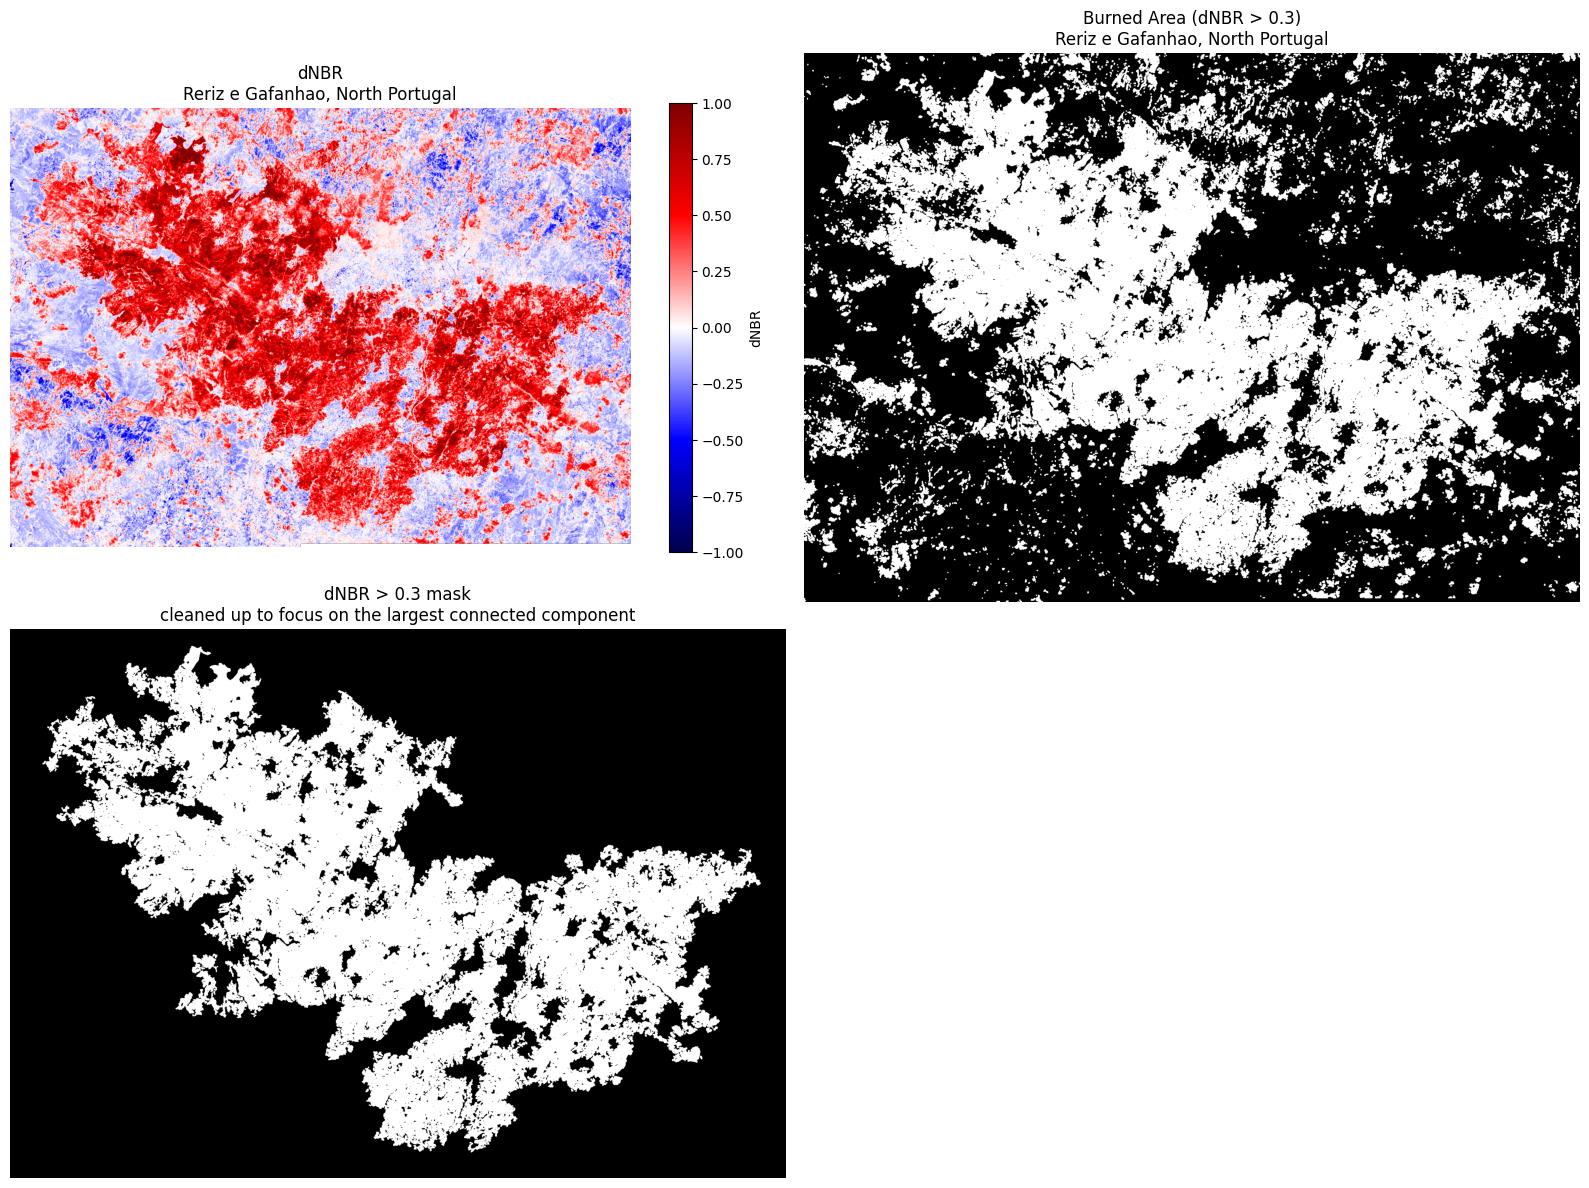

In [52]:
# Plotting original dNBR, masked dNBR, and a clean-up version of masked dNBR side by side
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax1, ax2, ax3, ax4 = axes.flat
fig.delaxes(ax4)

im1 = ax1.imshow(dnbr_gtiff, cmap="seismic", vmin=-1, vmax=1)
fig.colorbar(im1, ax=ax1, label="dNBR", shrink=0.8)
ax1.set_title(f"dNBR\n{current_params['location_name']}")
ax1.axis("off")

ax2.imshow(mask_gtif, cmap="gray")
ax2.set_title(f"Burned Area (dNBR > {burn_threshold_default})\n{current_params['location_name']}")
ax2.axis("off")

ax3.imshow(clean_mask, cmap='gray')
ax3.set_title(f"dNBR > {burn_threshold_default} mask\ncleaned up to focus on the largest connected component")
ax3.axis("off")

plt.tight_layout()
plt.show()

In [53]:
## NOTES
# # Using CDE either of these three work

# # Arithmetic
# dnbr = nbr_pre - nbr_post

# # With subtract process
# # from openeo.processes import subtract
# # dnbr = nbr_pre.subtract(nbr_post)

# # With merge_cubes
# # dnbr = nbr_pre.merge_cubes(nbr_post, overlap_resolver="subtract")

### 3.4 Export Fire Pixel Coordinates

In [ ]:
# Get centroid of every fire pixel in raster CRS
fire_rows, fire_cols = np.where(clean_mask == 1)
xs, ys = rasterio_xy(trans, fire_rows, fire_cols)

# Reproject to WGS84 (required by OpenEO) and build GeoJSON FeatureCollection
fire_points_gdf = geopandas.GeoDataFrame(
    geometry=geopandas.points_from_xy(xs, ys),
    crs=crs
).to_crs("EPSG:4326")

fire_points_geojson = json.loads(fire_points_gdf.to_json())

fire_points_file = "fire_points.geojson"
with open(fire_points_file, "w") as f:
    json.dump(fire_points_geojson, f)

print(f"Saved {len(fire_points_gdf)} fire pixel points to {fire_points_file}")

## 4. ML Vegetation Classification

### 4.1 Load NFI Labels on the Burned Area

In [ ]:
nfi_labels = geopandas.read_file("nfi_labels.geojson")

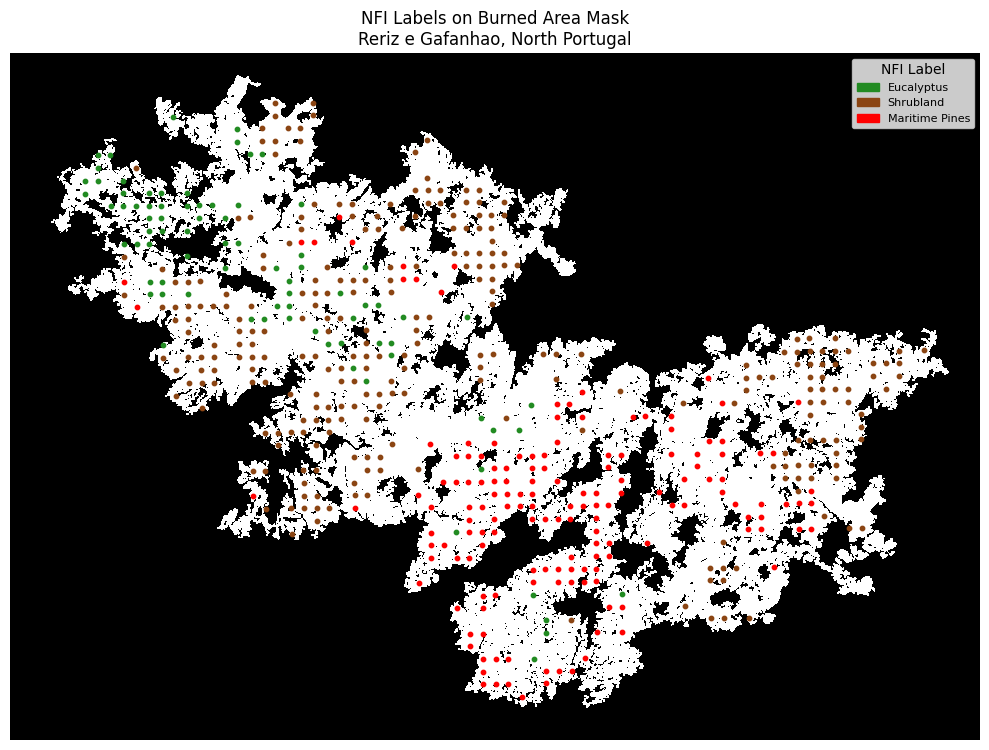

In [55]:
labels_raster_crs = nfi_labels.to_crs(crs)
rows, cols = rowcol(trans, labels_raster_crs.geometry.x.values, labels_raster_crs.geometry.y.values)

color_map = {
    "Shrubland": "saddlebrown",
    "Eucalyptus": "forestgreen",
    "Maritime Pines": "red",
}
default_color = "gray"

label_classes = nfi_labels["label"].unique()

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(clean_mask, cmap="gray", interpolation="none")

for cls in label_classes:
    mask_cls = nfi_labels["label"] == cls
    ax.scatter(cols[mask_cls], rows[mask_cls], s=10,
               color=color_map.get(cls, default_color), label=cls, zorder=2)

legend_patches = [mpatches.Patch(color=color_map.get(cls, default_color), label=cls) for cls in label_classes]
ax.legend(handles=legend_patches, loc="upper right", fontsize=8, title="NFI Label")
ax.set_title(f"NFI Labels on Burned Area Mask\n{current_params['location_name']}")
ax.axis("off")
plt.tight_layout()
plt.show()

### 4.2 Define ML Pipeline

In [57]:
def download_features(cube, geojson, out_folder="features_output"):
    """
    Aggregate spectral bands spatially over the given point set, submit a batch
    job, and return the downloaded timeseries as a Python list.
    """
    features = cube.aggregate_spatial(geojson, reducer="mean")
    job = features.create_job(out_format="JSON")
    job.start_and_wait()
    job.get_results().download_files(out_folder)
    with open(f"{out_folder}/timeseries.json") as f:
        return json.load(f)


def build_feature_matrix(raw, labels=None):
    """
    Convert raw aggregate_spatial output (list of per-point band values) to a
    numpy feature matrix. Returns (X, y) when labels are provided, else X only.
    """
    X = np.array(raw, dtype=float)
    if labels is not None:
        return X, labels["label"].values
    return X


def train_classifier(X, y):
    """Train a Random Forest on X/y and return the fitted model and a classification report."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    return clf, classification_report(y_test, clf.predict(X_test))

### 4.3 Train Random Forest Classifier

In [58]:
res = 20
s2cube = load_and_sample(current_params,  current_params["time_pre"].default, current_params["bands_ml"].default, res)

labels = nfi_labels
geojson = json.loads(labels[["label", "geometry"]].to_json())
raw = download_features(s2cube, geojson)
X, y = build_feature_matrix(raw, labels)
classifier, report = train_classifier(X, y)
print(report)

0:00:00 Job 'j-2607011003404cf686f3ad10d10f0a98': send 'start'
0:00:06 Job 'j-2607011003404cf686f3ad10d10f0a98': queued (progress 0%)
0:00:11 Job 'j-2607011003404cf686f3ad10d10f0a98': queued (progress 0%)
0:00:20 Job 'j-2607011003404cf686f3ad10d10f0a98': queued (progress 0%)
0:00:29 Job 'j-2607011003404cf686f3ad10d10f0a98': queued (progress 0%)
0:00:39 Job 'j-2607011003404cf686f3ad10d10f0a98': running (progress N/A)
0:00:51 Job 'j-2607011003404cf686f3ad10d10f0a98': running (progress N/A)
0:01:06 Job 'j-2607011003404cf686f3ad10d10f0a98': running (progress N/A)
0:01:26 Job 'j-2607011003404cf686f3ad10d10f0a98': running (progress N/A)
0:01:51 Job 'j-2607011003404cf686f3ad10d10f0a98': running (progress N/A)
0:02:21 Job 'j-2607011003404cf686f3ad10d10f0a98': running (progress N/A)
0:02:59 Job 'j-2607011003404cf686f3ad10d10f0a98': running (progress N/A)
0:03:46 Job 'j-2607011003404cf686f3ad10d10f0a98': running (progress N/A)
0:04:44 Job 'j-2607011003404cf686f3ad10d10f0a98': finished (progress 

### 4.4 Apply Classifier to Satellite Image

The fire area contains ~800,000 pixels. Downloading the full raster is too large for the backend (413 errors), and uploading all pixel coordinates as inline GeoJSON exceeds the WAF limit. Instead, we use `aggregate_spatial` to sample band values at a subset of fire pixel locations — the backend returns only the sampled values as JSON, avoiding any large raster transfer.

**Structure:**
1. **Setup** — load the fire pixel coordinates from disk, build the S2 cube once, set `n_points`
2. **Three sampling approaches** — each selects ~`n_points` locations differently, fetches band values via `aggregate_spatial`, runs `classifier.predict()`, and saves results to `.npz`
3. **Visualization** — loads all three `.npz` files and plots side by side for comparison

**Sampling approaches:**
- **First N** — takes the first `n_points` fire pixels in row-major (scan) order; fast but covers only the top strip of the fire area
- **Even sampling** — takes every `k`-th pixel in scan order (`k = total / n_points`); spreads across the full area but spacing is irregular in 2D
- **Grid sampling** — applies a regular stride in both row and column dimensions directly on the raster mask; produces a visually uniform dot grid over the fire shape

In [82]:
n_points = 10000
full_fire_gdf = geopandas.read_file(fire_points_file)
s2_pred_cube = load_and_sample(current_params, current_params["time_pre"].default, current_params["bands_ml"].default, res)

In [83]:
# First N points (row-major order, horizontal strip)
features_first_n = s2_pred_cube.aggregate_spatial(json.loads(full_fire_gdf.iloc[:n_points].to_json()), reducer="mean")
connection.download({"process_graph": features_first_n.save_result("JSON").flat_graph()}, "pred_first_n.json")

with open("pred_first_n.json") as f:
    preds_first_n = classifier.predict(build_feature_matrix(json.load(f)))
np.savez("pred_first_n.npz", predictions=preds_first_n, rows=fire_rows[:n_points], cols=fire_cols[:n_points])
print(dict(zip(*np.unique(preds_first_n, return_counts=True))))

{'Eucalyptus': np.int64(1349), 'Maritime Pines': np.int64(2807), 'Shrubland': np.int64(5844)}


In [84]:
# Even sampling (every n-th point in scan order)
step = len(full_fire_gdf) // n_points
fire_even = full_fire_gdf.iloc[::step]
even_indices = list(range(0, len(fire_rows), step))[:len(fire_even)]

features_even = s2_pred_cube.aggregate_spatial(json.loads(fire_even.to_json()), reducer="mean")
connection.download({"process_graph": features_even.save_result("JSON").flat_graph()}, "pred_even.json")

with open("pred_even.json") as f:
    preds_even = classifier.predict(build_feature_matrix(json.load(f)))
np.savez("pred_even.npz", predictions=preds_even, rows=fire_rows[even_indices], cols=fire_cols[even_indices])
print(dict(zip(*np.unique(preds_even, return_counts=True))))

{'Eucalyptus': np.int64(1409), 'Maritime Pines': np.int64(2563), 'Shrubland': np.int64(6075)}


In [85]:
# Grid sampling (regular 2D stride on the raster)
grid_stride = max(1, int(np.sqrt(len(fire_rows) / n_points)))
grid_mask = np.zeros_like(clean_mask, dtype=bool)
grid_mask[::grid_stride, ::grid_stride] = True
rows_grid, cols_grid = np.where(clean_mask.astype(bool) & grid_mask)

xs_g, ys_g = rasterio_xy(trans, rows_grid, cols_grid)
fire_grid = geopandas.GeoDataFrame(geometry=geopandas.points_from_xy(xs_g, ys_g), crs=crs).to_crs("EPSG:4326")

features_grid = s2_pred_cube.aggregate_spatial(json.loads(fire_grid.to_json()), reducer="mean")
connection.download({"process_graph": features_grid.save_result("JSON").flat_graph()}, "pred_grid.json")

with open("pred_grid.json") as f:
    preds_grid = classifier.predict(build_feature_matrix(json.load(f)))
np.savez("pred_grid.npz", predictions=preds_grid, rows=rows_grid, cols=cols_grid)
print(f"stride={grid_stride}, n={len(rows_grid)}: {dict(zip(*np.unique(preds_grid, return_counts=True)))}")

stride=8, n=12589: {'Eucalyptus': np.int64(1848), 'Maritime Pines': np.int64(3168), 'Shrubland': np.int64(7573)}


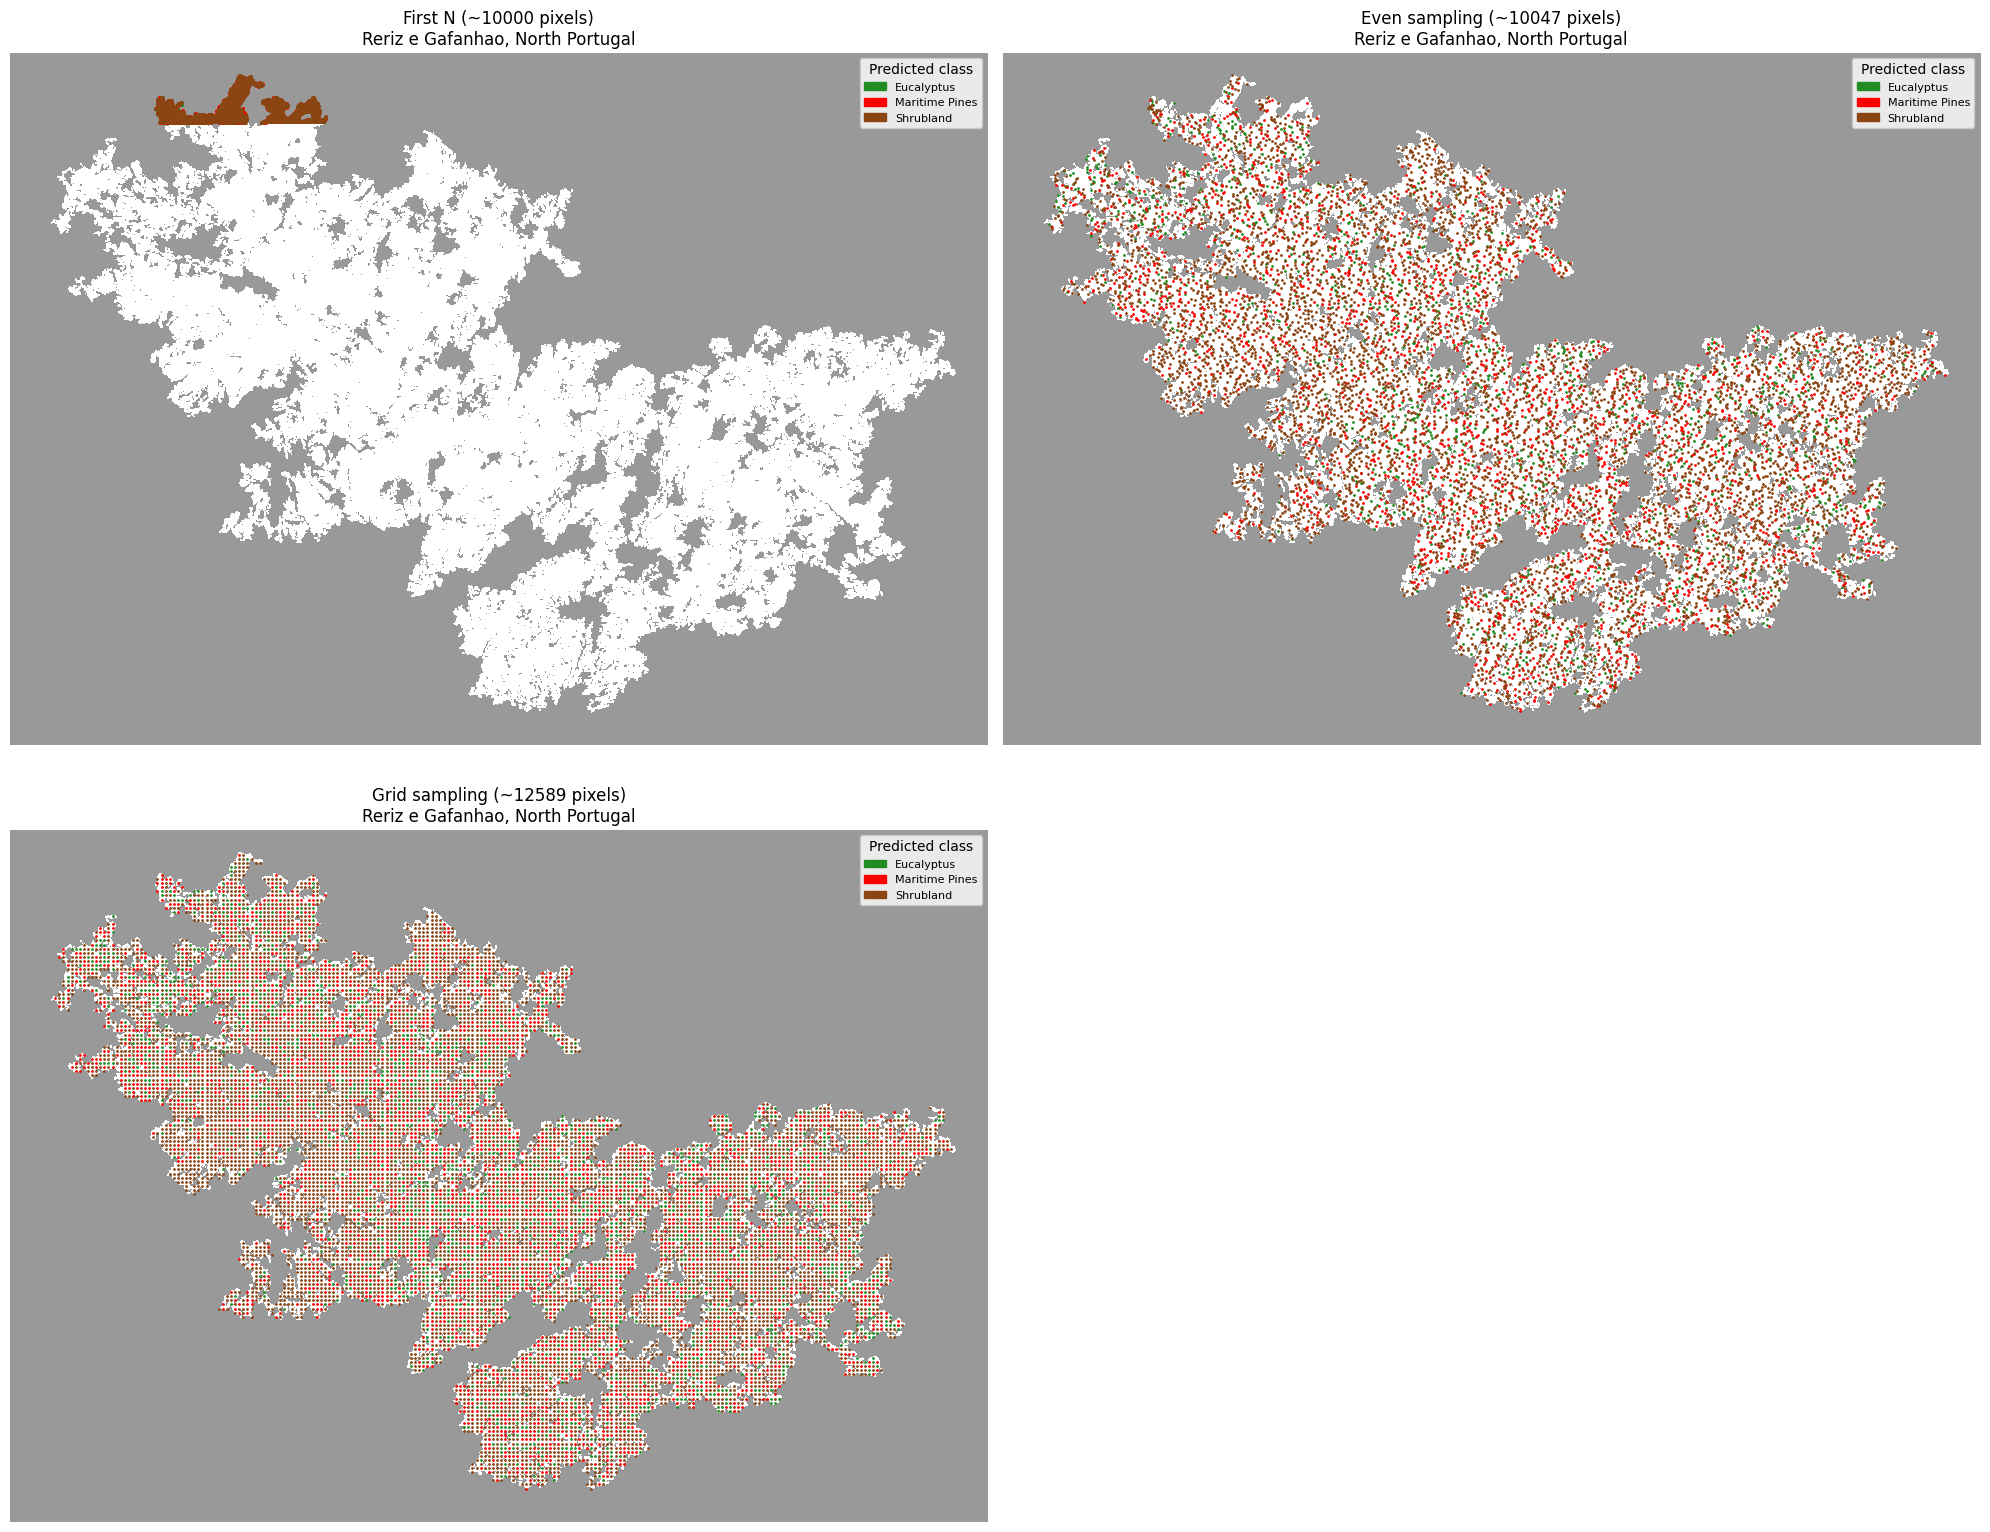

In [91]:
color_map = {"Shrubland": "saddlebrown", "Eucalyptus": "forestgreen", "Maritime Pines": "red"}

datasets = [
    ("First N", np.load("pred_first_n.npz", allow_pickle=True)),
    ("Even sampling", np.load("pred_even.npz", allow_pickle=True)),
    ("Grid sampling", np.load("pred_grid.npz", allow_pickle=True)),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
ax1, ax2, ax3, ax4 = axes.flat
fig.delaxes(ax4)

for ax, (title, data) in zip([ax1, ax2, ax3], datasets):
    preds = data["predictions"]
    ax.imshow(clean_mask, cmap="gray", interpolation="none", alpha=0.4)
    for cls in np.unique(preds):
        mask_cls = preds == cls
        ax.scatter(data["cols"][mask_cls], data["rows"][mask_cls], s=1,
                   color=color_map.get(cls, "gray"), zorder=2)
    legend_patches = [mpatches.Patch(color=color_map.get(cls, "gray"), label=cls) for cls in np.unique(preds)]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=8, title="Predicted class")
    ax.set_title(f"{title} (~{len(preds)} pixels)\n{current_params['location_name']}")
    ax.axis("off")

plt.tight_layout()
plt.show()